In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_path = "/content/drive/MyDrive/ViT-models/best_model.pth"
dense_path = "/content/drive/MyDrive/models/best_model.pth"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DenseNet Architecture

In [ ]:
# Bottle Neck Layer
class Bottleneck(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        inter_channels = 4 * growth_rate

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return torch.cat([x, out], 1)

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        layers = []

        for i in range(num_layers):
            layers.append(Bottleneck(in_channels + i * growth_rate, growth_rate))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Transition Layer
class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(F.relu(self.bn(x)))
        x = self.pool(x)
        return x

# DenseNet
class DenseNet(nn.Module):
    def __init__(self, block_config=(6, 12, 24, 16), growth_rate=32, reduction=0.5, num_classes=5):
        super().__init__()

        num_init_features = 2 * growth_rate

        # First conv
        self.features = nn.Sequential(
            nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(num_init_features),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        num_features = num_init_features

        # Dense blocks
        for i, num_layers in enumerate(block_config):
            block = DenseBlock(num_layers, num_features, growth_rate)
            self.features.add_module(f"denseblock{i+1}", block)

            num_features += num_layers * growth_rate

            if i != len(block_config) - 1:
                out_features = int(num_features * reduction)
                trans = Transition(num_features, out_features)
                self.features.add_module(f"transition{i+1}", trans)
                num_features = out_features

        # Final BN
        self.features.add_module("norm5", nn.BatchNorm2d(num_features))

        # Classifier
        self.classifier = nn.Linear(num_features, num_classes)

        # Init weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)

        x = self.classifier(x)
        return x


def densenet121(num_classes=5):
    return DenseNet(block_config=(6, 12, 24, 16), growth_rate=32, num_classes=num_classes)


ViT Architecture

In [ ]:
# Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)        # (B, embed_dim, H', W')
        x = x.flatten(2)        # (B, embed_dim, N)
        x = x.transpose(1, 2)   # (B, N, embed_dim)
        return x
# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
      x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
      x = x + self.mlp(self.norm2(x))
      return x

#ViT model
class ViT(nn.Module):
  def __init__(self,img_size=224, patch_size=16,num_classes=10, embed_dim=256, depth=6, num_heads=8):
    super().__init__()
    self.patch_embedding = PatchEmbedding(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=3,
    embed_dim=embed_dim
    )
    num_patches = (img_size // patch_size) ** 2
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
    self.transformer = nn.Sequential(
        *[TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Linear(embed_dim, num_classes)
    )

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.shape[0]
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.pos_embedding
    x = self.transformer(x)
    x = x[:, 0]
    x = self.mlp_head(x)
    return x

Load dataset

In [ ]:


batch_size = 32
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.25MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.2MB/s]


Load pretrain model

In [ ]:

vit_model = ViT(
    num_classes=10,
    patch_size=8,
    embed_dim=128,
    num_heads=8
).to(device)

dense_model = densenet121(num_classes=10).to(device)

def load_weights(model, path):
    ckpt = torch.load(path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    return model
vit_model = load_weights(vit_model, vit_path)
dense_model = load_weights(dense_model, dense_path)
vit_model.eval()
dense_model.eval()

DenseNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (block): Sequential(
        (0): Bottleneck(
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (1): Bottleneck(
          (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
     

In [ ]:


all_preds = []
all_labels = []

vit_model.eval()
dense_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward 2 model
        logits_vit = vit_model(images)
        logits_dense = dense_model(images)

        # Ensemble theo logits
        final_logits = 0.5 * logits_vit + 0.5 * logits_dense
        preds = final_logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ===== Metrics =====
acc = accuracy_score(all_labels, all_preds)
print("Ensemble Accuracy:", acc)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1-score  :", f1)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

Ensemble Accuracy: 0.9454
Precision : 0.9456109227015865
Recall    : 0.9454
F1-score  : 0.9454662626336511

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1000
           1       1.00      0.99      0.99      1000
           2       0.94      0.92      0.93      1000
           3       0.94      0.95      0.94      1000
           4       0.93      0.93      0.93      1000
           5       0.99      0.98      0.99      1000
           6       0.83      0.84      0.83      1000
           7       0.97      0.99      0.98      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.97      0.98      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



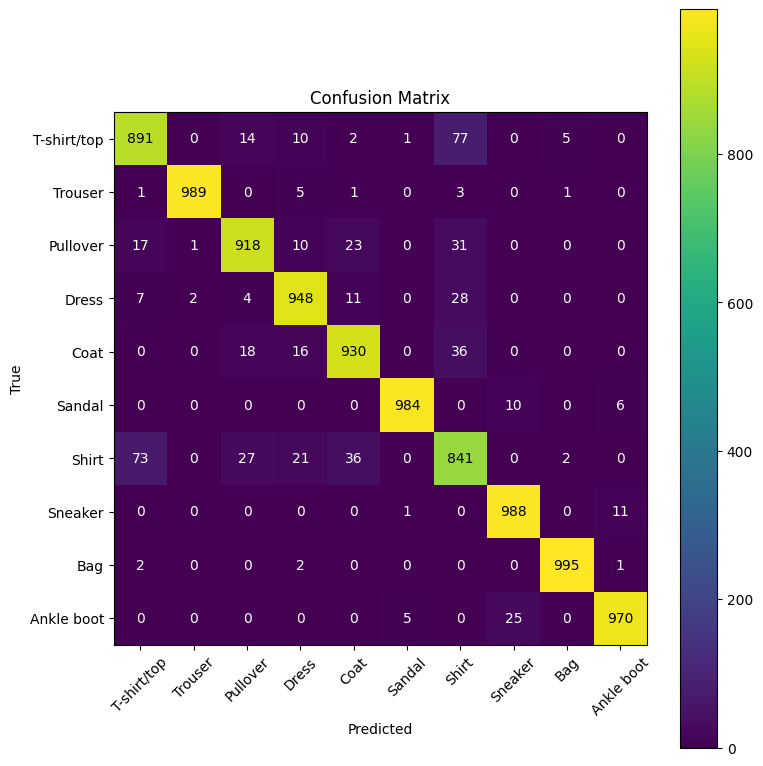

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = train_dataset.classes

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black" if cm[i, j] > cm.max()/2 else "white")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()